<a href="https://colab.research.google.com/github/lakshuu-jay/Projects/blob/main/BookRecommendationDataExplorer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


Books available in the Gutenberg corpus:
['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']

Structured Book Dataset:
                book  total_words  unique_words
0        Austen Emma       192427          7079
1  Austen Persuasion        98171          5739
2       Austen Sense       141576          6283
3          Bible Kjv      1010654         12568
4        Blake Poems         8354          1510

Missing Values:
book            0
total_words     0
unique_words    0
dtype: int64

Book Features:
                book  total_words  unique_words  vocabulary_ratio
0        Austen Emma       192427          7079          0.

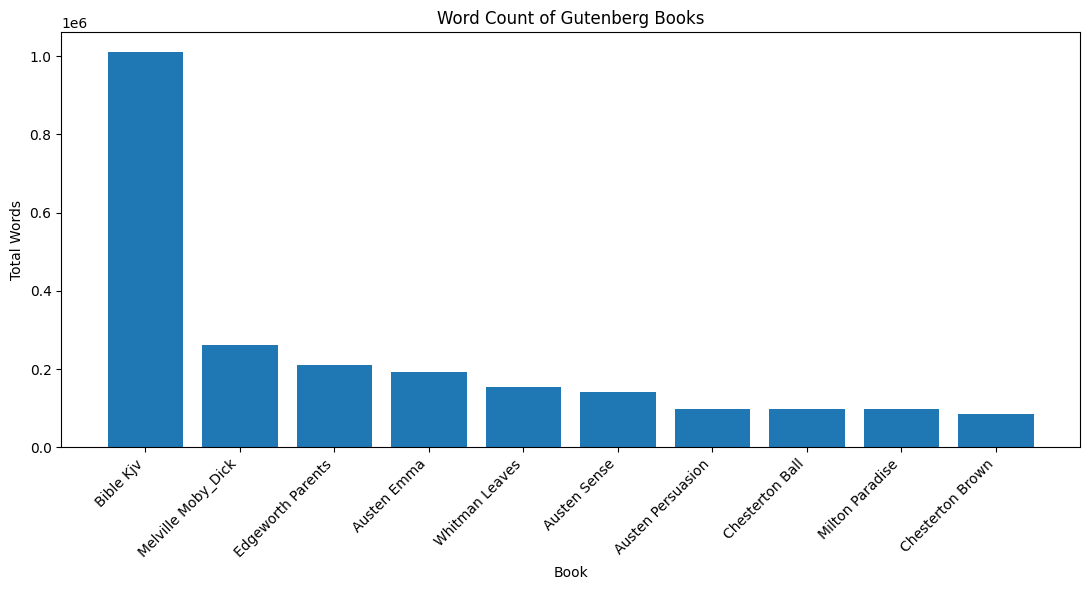

In [2]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt

nltk.download("gutenberg")

from nltk.corpus import gutenberg

book_files = gutenberg.fileids()

print("Books available in the Gutenberg corpus:")
print(book_files)

book_data = []

for file_name in book_files:

    words = gutenberg.words(file_name)

    title = (
        file_name
        .replace(".txt", "")
        .replace("-", " ")
        .title()
    )

    total_words = len(words)


    unique_words = len(
        set(
            word.lower()
            for word in words
            if word.isalpha()
        )
    )


    book_data.append(
        {
            "book": title,
            "total_words": total_words,
            "unique_words": unique_words
        }
    )

books_df = pd.DataFrame(book_data)

print("\nStructured Book Dataset:")
print(books_df.head())


print("\nMissing Values:")
print(books_df.isnull().sum())

books_df = books_df.drop_duplicates(
    subset="book"
)


books_df["vocabulary_ratio"] = (
    books_df["unique_words"]
    / books_df["total_words"]
)

print("\nBook Features:")
print(books_df.head())


books_df = books_df.sort_values(
    "total_words",
    ascending=False
)

print("\nBooks Sorted by Length:")
print(books_df)


selected_book = "Austen Emma"

selected_length = books_df.loc[
    books_df["book"] == selected_book,
    "total_words"
].iloc[0]

books_df["length_difference"] = abs(
    books_df["total_words"]
    - selected_length
)

recommendations = (
    books_df[
        books_df["book"] != selected_book
    ]
    .sort_values("length_difference")
    .head(5)
)

print(
    "\nBooks similar in length to",
    selected_book
)

print(
    recommendations[
        [
            "book",
            "total_words",
            "unique_words"
        ]
    ]
)


top_books = books_df.head(10)

plt.figure(figsize=(11, 6))

plt.bar(
    top_books["book"],
    top_books["total_words"]
)

plt.title("Word Count of Gutenberg Books")
plt.xlabel("Book")
plt.ylabel("Total Words")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()
